<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_06_4_prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 6: Time Series in PyTorch**  

- Instructor: [Jeff Heaton](https://sites.wustl.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.wustl.edu/Programs/Pages/default.aspx)
- For more information visit the [class website](https://sites.wustl.edu/jeffheaton/t81-558/).

# Module 6 Material

* Part 6.1: Time Series Data Encoding for Deep Learning, PyTorch [[Video]]() [[Notebook]](t81_558_class_06_1_timeseries.ipynb)
* Part 6.2: LSTM-Based Time Series with PyTorch [[Video]]() [[Notebook]](t81_558_class_06_2_lstm.ipynb)
* Part 6.3: Transformer-Based Time Series with PyTorch [[Video]]() [[Notebook]](t81_558_class_06_3_transformer_timeseries.ipynb)
* **Part 6.4: Predicting with Meta Prophet** [[Video]]() [[Notebook]](t81_558_class_06_4_prophet.ipynb)
* Part 6.5: Vibe Coding a Toy SP500 Model [[Video]]() [[Notebook]](t81_558_class_06_5_sp500.ipynb)


# Google CoLab Instructions

The following code checks whether this notebook is running in Google CoLab and sets up the correct hardware settings for PyTorch.


In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except ImportError:
    COLAB = False
    print("Note: not using Google CoLab")

# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: using Google CoLab
Using device: cuda


# Part 6.4: Predicting with Meta Prophet
The previous parts of this module explored LSTM and transformer-based architectures for time series forecasting — approaches that require careful sequence construction, model design, and training. This part introduces a different philosophy: automated time series forecasting using Meta's Prophet library.

Prophet, originally developed by Facebook's Core Data Science team and released as open source, takes an additive modeling approach. It decomposes a time series into trend, seasonality, and holiday effects, then fits each component separately using a curve-fitting procedure backed by Stan. The result is a model that requires almost no configuration, handles missing data and outliers gracefully, and produces interpretable component plots showing exactly what it learned.
This makes Prophet a useful tool when you need a strong, explainable baseline quickly — particularly for business time series with clear weekly and yearly seasonality, such as sales, web traffic, or demand forecasting. Unlike the neural approaches earlier in this module, Prophet does not learn from raw sequences of lagged values. Instead, it models time explicitly as a function of calendar structure, which is both its strength and its limitation.

In this part, we apply Prophet to a restaurant sales dataset spanning three years. We will train the model on historical daily sales totals, forecast one year into the future, and examine the trend and seasonality components Prophet automatically discovers. We will also use Plotly to generate interactive versions of the forecast plots.
By the end of this part, you should be comfortable loading time series data into Prophet's required format, fitting and forecasting with the default model, interpreting the component decomposition, and knowing when Prophet is the right tool versus when a neural approach is warranted.
## Install Prophet

Prophet is not installed by default in Google CoLab, so the cell below installs it on the fly. If you are running locally and already have `prophet` installed, the install will simply confirm the current version.

In [2]:
if COLAB:
    !pip install -q --upgrade prophet

This notebook makes use of Meta (formerly Facebook) [Prophet](https://facebook.github.io/prophet/) to forecast time series. Prophet fits an additive model with non-linear trend, yearly/weekly/daily seasonality, and holiday effects, and works well on series with several seasons of history.

In [3]:
import pandas as pd

BASE_URL = "https://data.heatonresearch.com/wustl/CABI/demand-forecast"

df_sales = pd.read_csv(f"{BASE_URL}/sales_train.csv")
df_items = pd.read_csv(f"{BASE_URL}/items.csv")
# NOTE: the file on the server is intentionally named 'resturants.csv' (sic);
# the Python variable below uses the correct spelling.
df_restaurants = pd.read_csv(f"{BASE_URL}/resturants.csv")

df_sales["date"] = pd.to_datetime(df_sales["date"], errors="coerce")

Begin by producing a line graph of all sales over the provided 3-year timespan. We will use this aggregated series to train Prophet.

In [4]:
import plotly.express as px

df_plot = (
    df_sales[["date", "item_count"]]
    .groupby("date", as_index=False)
    .sum()
)
fig = px.line(df_plot, x="date", y="item_count", title="Total Sales by Date")
fig.show()

Construct the Prophet model and put the previous data into the form expected by Prophet (a DataFrame with columns `ds` for the date and `y` for the value).

In [5]:
from prophet import Prophet

df_prophet = df_plot.rename(columns={"date": "ds", "item_count": "y"})

m = Prophet()
m.fit(df_prophet)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Predict one year into the future.

In [6]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
1091,2022-12-27
1092,2022-12-28
1093,2022-12-29
1094,2022-12-30
1095,2022-12-31


Display the predicted tabular data.

In [7]:
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1091,2022-12-27,339.479744,283.471875,392.775241
1092,2022-12-28,401.302482,346.637756,455.912435
1093,2022-12-29,576.463729,516.380334,632.015424
1094,2022-12-30,701.171119,647.244995,756.341859
1095,2022-12-31,698.452052,641.144763,750.808973


Plot the future predictions.

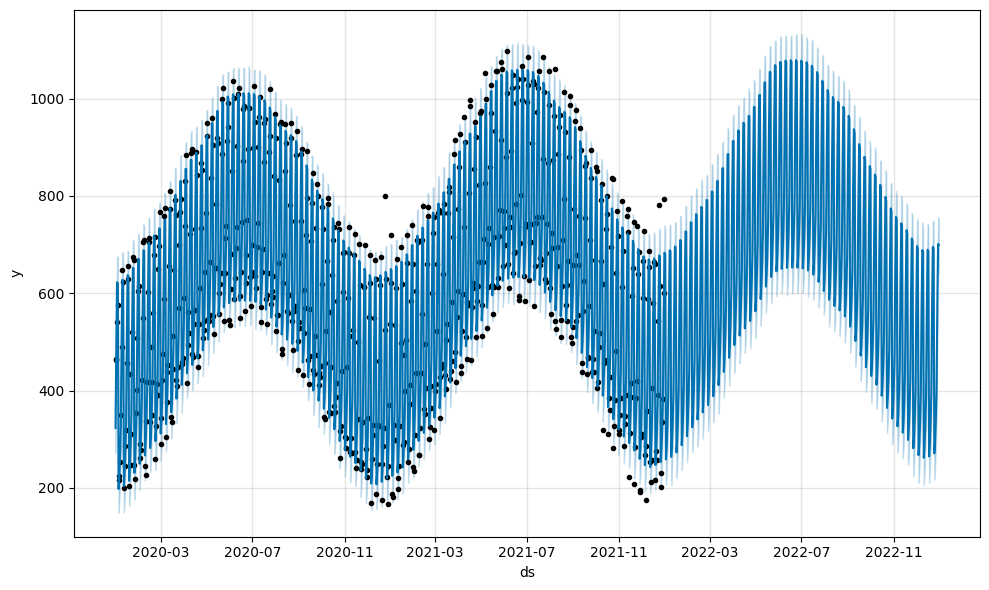

In [8]:
fig1 = m.plot(forecast)

See what seasonality and trend were detected.

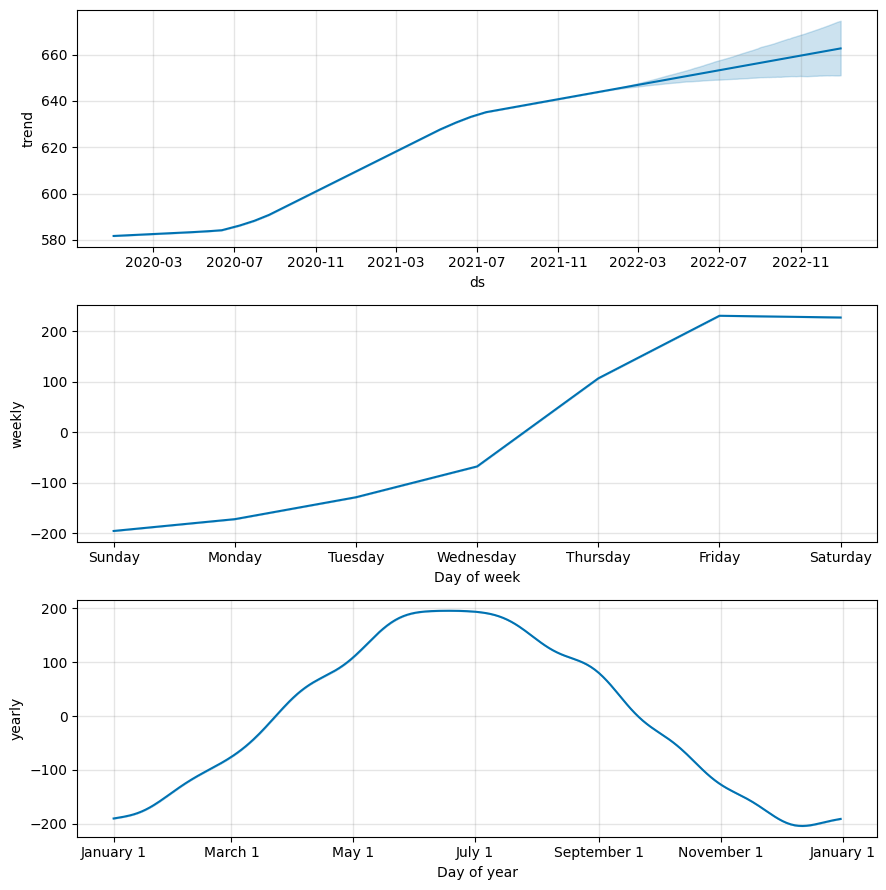

In [9]:
fig2 = m.plot_components(forecast)

Use Plotly to generate an interactive plot. `plot_plotly` returns a Plotly `Figure` object, so we call `.show()` on it to display it in the notebook.

In [10]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast).show()

And the same components plot, rendered interactively with Plotly:

In [11]:
plot_components_plotly(m, forecast).show()

/usr/local/lib/python3.12/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.

